# 第5章 Taxi：大きな表と、探索の工夫（ε の減衰・行動マスク）

5 × 5 のマス目の町を、タクシーが走ります。町の四隅に近い4か所に乗り場（R・G・Y・B）があり、そのどこかで客が待っています。タクシーは、客のいる乗り場まで行って客を乗せ、客の行き先の乗り場まで運んで降ろせば成功です。町には壁があって、通れない所もあります。1歩ごとに報酬が -1 され、見当違いの場所で乗せ降ろしをしようとすると -10、正しく送り届けると +20 です。

この章では、この **Taxi** を、第3・4章と同じ Q学習で解きます。新しいのは、表の大きさです。タクシーの位置・客の居場所・行き先の組み合わせで、状態は 500 個になり、FrozenLake（16 個）や CliffWalking（48 個）よりずっと多くなります。表が大きくなると、でたらめに試すだけでは、良い行動を見つけるまでに時間がかかります。そこでこの章では、探索の2つの工夫を使います。1つは、学習の始めはでたらめに試し、だんだんでたらめを減らしていく **ε の減衰**、もう1つは、その状態で意味のある行動だけから選ぶ **行動マスク** です。まず、2つの工夫を入れたサンプルを動かして、タクシーが客を運べるようになる様子を楽しみます。次に、サンプルを読み、最後に、工夫を外したときと比べます。

- **前提**: [第3章 FrozenLake](../ch03_frozenlake/ch03_frozenlake.ipynb)と[第4章 CliffWalking](../ch04_cliffwalking/ch04_cliffwalking.ipynb)を終えていること
- **所要の目安**: 実行は CPU で 1〜2 分ほど
- **使う装置**: CPU だけで動きます（計算は NumPy だけです）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、NumPy 2.5.3）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. Taxi の状態（500 個）・行動（6 個）・報酬と、状態の番号の読み方を説明できる
2. 用意した Q学習のサンプルを動かし、学習後のタクシーが客を運ぶ様子と、学習曲線を見られる
3. ε の減衰と行動マスクが、サンプルのどの行に当たるかを説明できる
4. ε を一定にするか減らすか、行動マスクを使うか使わないかの4通りを比べ、何が変わるかを説明できる

完了条件は、この Notebook を上から最後まで実行して、4節で学習した方策が、1,000 回の評価で報酬の平均 8 以上になることです（Gymnasium は、Taxi を「解けた」とみなす目安を、報酬の平均 8 としています）。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | Taxi を知る | 町の地図、状態の番号、報酬と行動マスク、でたらめに運転したときの成績 |
| 4節 | 動かして楽しむ：Q学習のサンプルを動かす | 学習後の成績、客を運ぶ様子、学習曲線 |
| 5節 | 読む(1)：Q 表 | 500 × 6 の表の中身 |
| 6節 | 読む(2)：サンプル | ε の減衰、行動マスク |
| 7節 | 比べる：工夫を外す | 4通りの設定の学習曲線と成績 |
| 8節 | 遊んでみる | 雨の日の町、学習の回数 |

この章の Q学習は、第3章と同じく、概要資料の[強化学習の手法の地図](../../overview/rl.md)の「表で覚える」領域にあります。概要資料の3-1節で紹介した「探索と活用」の釣り合いを、ε の減衰で調整します。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う2つの関数を用意します。

In [1]:
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

ACTION_NAMES = ["SOUTH", "NORTH", "EAST", "WEST", "PICKUP", "DROPOFF"]  # 行動の番号 0〜5 の意味
LOCATION_NAMES = ["R", "G", "Y", "B"]  # 乗り場の番号 0〜3 の名前（客の居場所の 4 は「タクシーの中」）
LOCATION_COLORS = ["#f4b6b6", "#b8e0b0", "#f6e3a1", "#b6cdf2"]


# 町の地図と、状態 state の様子（タクシー・客・行き先）を描く
def draw_taxi(ax, env, state, title=None):
    u = env.unwrapped
    taxi_row, taxi_col, passenger, destination = u.decode(state)
    for row in range(5):
        for col in range(5):
            ax.add_patch(plt.Rectangle((col, row), 1, 1, facecolor="#f4f4ee", edgecolor="lightgray"))
    for i, (row, col) in enumerate(u.locs):
        ax.add_patch(plt.Rectangle((col, row), 1, 1, facecolor=LOCATION_COLORS[i], edgecolor="lightgray"))
        ax.text(col + 0.12, row + 0.3, LOCATION_NAMES[i], fontsize=11, fontweight="bold")
    # 行き先の乗り場を太い枠で囲む
    dest_row, dest_col = u.locs[destination]
    ax.add_patch(plt.Rectangle((dest_col + 0.05, dest_row + 0.05), 0.9, 0.9, fill=False, edgecolor="black", lw=3))
    # 壁（地図の文字列の "|"）を太い線で描く
    for row in range(5):
        for col in range(4):
            if u.desc[row + 1, 2 * col + 2] == b"|":
                ax.plot([col + 1, col + 1], [row, row + 1], color="black", lw=4)
    ax.plot([0, 5, 5, 0, 0], [0, 0, 5, 5, 0], color="black", lw=4)
    # タクシー（客が乗っていれば緑、空車なら橙）と、乗り場で待つ客（黒い丸）
    color = "tab:green" if passenger == 4 else "tab:orange"
    ax.add_patch(plt.Rectangle((taxi_col + 0.2, taxi_row + 0.25), 0.6, 0.5, facecolor=color, edgecolor="black", zorder=3))
    if passenger < 4:
        p_row, p_col = u.locs[passenger]
        ax.add_patch(plt.Circle((p_col + 0.75, p_row + 0.75), 0.15, color="black", zorder=4))
    ax.set_xlim(-0.1, 5.1)
    ax.set_ylim(5.1, -0.1)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10)


# Q 表から、Q 値が最大の行動を選ぶ方策で episodes 回運転させ、報酬の合計の平均と、客を送り届けた割合を返す
# use_mask=True なら、行動マスクで許された行動の中から選ぶ
def evaluate(env, q_table, use_mask, episodes=1000, seed=100):
    rng = np.random.default_rng(seed)
    totals = np.zeros(episodes)
    delivered = 0
    for i in range(episodes):
        state, info = env.reset(seed=seed if i == 0 else None)
        while True:
            mask = info["action_mask"] if use_mask else None
            action = greedy_action(q_table, state, rng, mask)
            state, reward, terminated, truncated, info = env.step(action)
            totals[i] += reward
            if terminated or truncated:
                delivered += terminated
                break
    return totals.mean(), delivered / episodes


# 状態 state で Q 値が最大の行動を1つ返す（最大が複数あればでたらめに選ぶ。mask を渡すと、許された行動の中から選ぶ）
def greedy_action(q_table, state, rng, mask=None):
    values = q_table[state] if mask is None else np.where(mask == 1, q_table[state], -np.inf)
    best = np.flatnonzero(values == values.max())
    return int(rng.choice(best))

関数の説明:

- `draw_taxi` は、町の地図と、ある状態の様子を matplotlib で描く関数です。4か所の乗り場（R・G・Y・B）を色付きのマスで、壁を太い線で描きます。タクシーは四角で、空車なら橙、客が乗っていれば緑です。乗り場で待っている客は黒い丸、客の行き先の乗り場は太い枠で示します
- `evaluate` は、学習した Q 表から Q 値が最大の行動を選ぶ方策で 1,000 回運転させ、報酬の合計の平均と、客を送り届けた割合を返す関数です。第3章の `success_rate` と同じく、最初の `reset` にだけ `seed` を渡します
- `greedy_action` は、第3・4章と同じく Q 値が最大の行動を選ぶ関数に、行動マスク（3-3節）で許された行動だけから選ぶ機能を足したものです

Gymnasium にも Taxi の絵を描く機能がありますが、これまでの章と同じく、その絵には Gymnasium のライセンスとは別の作者の画像素材が使われています。この章でも、その絵を載せずに、`draw_taxi` で描いた図を使います。

## 3. Taxi を知る

### 3-1. 環境を作る

In [2]:
env = gym.make("Taxi-v4")
print(env)
print("エピソードの上限の回数:", env.spec.max_episode_steps)
print("「解けた」とみなす報酬の目安:", env.spec.reward_threshold)
print("観測の空間:", env.observation_space)
print("行動の空間:", env.action_space)

<TimeLimit<OrderEnforcing<PassiveEnvChecker<TaxiEnv<Taxi-v4>>>>>
エピソードの上限の回数: 200
「解けた」とみなす報酬の目安: 8
観測の空間: Discrete(500)
行動の空間: Discrete(6)


**期待する結果**（上の出力の読み方）: 1行目から、第3章の FrozenLake と同じく、本体の `TaxiEnv` を `TimeLimit` を含む3つのラッパーが包んでいることが分かります。エピソードの上限は 200 回で、「解けた」とみなす目安は報酬 8 です。

観測の空間は `Discrete(500)` で、状態は 0〜499 の整数1つです。行動の空間は `Discrete(6)` で、0 が南（`SOUTH`、図の下）、1 が北（`NORTH`、上）、2 が東（`EAST`、右）、3 が西（`WEST`、左）へ1マス進む移動、4 が客を乗せる（`PICKUP`）、5 が客を降ろす（`DROPOFF`）です。

この章では、Gymnasium 1.3.0 の `Taxi-v4` を使います。著者が確かめたところ、1.3.0 では `gym.make("Taxi-v3")` はエラーになり、`Taxi-v4` を使うように案内されました（Gymnasium 1.3.0 のソースの説明〈版の履歴〉によると、v4 では雨の日の設定〈8-1節〉などの実装が直されています）。

### 3-2. 状態の番号を読む

`reset` で最初の状態を受け取り、`decode` で4つの数に分けて、町の地図に描きます。

状態の番号: 314
タクシーの位置: 3 行 0 列、客の居場所: 3（B）、行き先: 2（Y）
encode で番号に戻す: 314


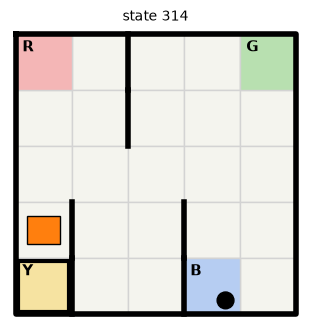

In [3]:
state, info = env.reset(seed=0)
taxi_row, taxi_col, passenger, destination = env.unwrapped.decode(state)
print("状態の番号:", state)
print(f"タクシーの位置: {taxi_row} 行 {taxi_col} 列、客の居場所: {passenger}（{LOCATION_NAMES[passenger]}）、"
      f"行き先: {destination}（{LOCATION_NAMES[destination]}）")
print("encode で番号に戻す:", env.unwrapped.encode(taxi_row, taxi_col, passenger, destination))

fig, ax = plt.subplots(figsize=(3.4, 3.4))
draw_taxi(ax, env, state, title=f"state {state}")
fig.tight_layout()
fig.savefig(FIGURES / "ch05_map.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 最初の状態は 314 で、`decode` で分けると、タクシーは 3 行 0 列（左の列の、下から2番目のマス）、客の居場所は 3（乗り場 B）、行き先は 2（乗り場 Y）です。`encode` で4つの数を番号に戻すと、314 に戻ります。図では、橙のタクシーが左の列に、黒い丸の客が下の段の右から2番目の B に、太い枠が左下の Y にあります。

状態の番号は、((行 × 5 + 列) × 5 + 客の居場所) × 4 + 行き先、で決まっています。3-2節の例では、((3 × 5 + 0) × 5 + 3) × 4 + 2 = 314 です。タクシーの位置が 25 通り、客の居場所が 5 通り（4か所の乗り場とタクシーの中）、行き先が 4 通りなので、状態は 25 × 5 × 4 = 500 個になります。

### 3-3. 報酬と行動マスク

`reset` と `step` が返す `info` には、`action_mask` という配列が入っています。6 つの行動のそれぞれについて、その状態で選んで意味があるか（1）、無いか（0）を表します。3-2節の状態で見てから、わざと乗り場でない所で `PICKUP`（行動 4）を選んでみます。

In [4]:
print("info:", info)
print("許された行動:", [ACTION_NAMES[a] for a in np.flatnonzero(info["action_mask"])])
state, reward, terminated, truncated, info = env.step(4)  # PICKUP（客のいない所で乗せようとする）
print(f"PICKUP → 状態 {state}、報酬 {reward}、terminated={terminated}")

info: {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)}
許された行動: ['SOUTH', 'NORTH']
PICKUP → 状態 314、報酬 -10、terminated=False


**期待する結果**（上の出力の読み方）: 最初の状態の `action_mask` は `[1, 1, 0, 0, 0, 0]` で、許されているのは `SOUTH` と `NORTH` だけです。図のとおり、タクシーの右には壁があり、左は町の端なので、`EAST` と `WEST` では動けません。客も乗っておらず、客のいる乗り場でもないので、`PICKUP` と `DROPOFF` も許されていません。

許されていない `PICKUP` を選ぶと、報酬は -10 で、状態は 314 のまま変わりません。`terminated=False` で、エピソードも続きます。

### 3-4. でたらめに運転する

でたらめに行動を選んで 1,000 回運転させ、報酬の合計の平均と、客を送り届けた割合を測ります。6 つの行動からでたらめに選ぶ場合と、行動マスクで許された行動からでたらめに選ぶ場合を比べます。

In [5]:
for use_mask in [False, True]:
    env.action_space.seed(100)
    totals, delivered = [], 0
    for i in range(1000):
        state, info = env.reset(seed=100 if i == 0 else None)
        total = 0
        while True:
            action = env.action_space.sample(info["action_mask"]) if use_mask else env.action_space.sample()
            state, reward, terminated, truncated, info = env.step(action)
            total += reward
            if terminated or truncated:
                delivered += terminated
                break
        totals.append(total)
    label = "マスクあり" if use_mask else "マスクなし"
    print(f"{label}: 報酬の合計の平均 {np.mean(totals):7.1f}、客を送り届けた割合 {delivered / 1000:.1%}")

マスクなし: 報酬の合計の平均  -766.1、客を送り届けた割合 5.4%


マスクあり: 報酬の合計の平均  -186.5、客を送り届けた割合 13.1%


**期待する結果**（上の出力の読み方）: 6 つの行動からでたらめに選ぶと、報酬の合計の平均は -766.1 で、客を送り届けられたのは 5.4% だけです。行動マスクで許された行動からでたらめに選ぶと、平均は -186.5、送り届けた割合は 13.1% になります。

1歩ごとの -1 だけなら、200 回の上限まで運転しても、報酬の合計は -200 までしか下がりません。マスクなしの平均が -200 を大きく下回っているのは、-10 の乗せ降ろしを何度も選んでいるためです。マスクありでは、-10 になる行動を選ぶことがありません。

## 4. 動かして楽しむ：Q学習のサンプルを動かす

### 4-1. 学習させる

用意した Q学習のサンプルで、エピソードを 3,000 回経験させます。ε（でたらめに選ぶ確率）は、最初の 1.0 から、学習の前半の 1,500 回で 0.05 まで少しずつ減らし、後半は 0.05 のままにします。行動は、行動マスクで許された行動の中から選びます。サンプルの中身は6節で読むので、ここでは実行して結果を見てください。

In [6]:
# ε の減衰: 最初の decay_episodes 回で、epsilon_start から epsilon_end まで一定の割合で減らし、そのあとは epsilon_end のままにする
def epsilon_schedule(i, epsilon_start, epsilon_end, decay_episodes):
    if i >= decay_episodes:
        return epsilon_end
    return epsilon_start + (epsilon_end - epsilon_start) * i / decay_episodes


# Q学習で episodes 回のエピソードを経験させ、Q 表と、エピソードごとの報酬の合計・-10 の行動の回数・ε を返す
def q_learning(env, episodes, use_mask=True, epsilon_start=1.0, epsilon_end=0.05, decay_episodes=None,
               alpha=0.1, gamma=0.99, seed=0):
    if decay_episodes is None:
        decay_episodes = episodes // 2  # 指定が無ければ、前半で減らしきる
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = np.zeros(episodes)
    illegal = np.zeros(episodes, dtype=int)
    epsilons = np.zeros(episodes)
    for i in range(episodes):
        epsilon = epsilon_schedule(i, epsilon_start, epsilon_end, decay_episodes)
        epsilons[i] = epsilon
        state, info = env.reset(seed=seed if i == 0 else None)
        while True:
            mask = info["action_mask"] if use_mask else None
            if rng.random() < epsilon:  # 探索: でたらめに選ぶ（マスクがあれば、許された行動の中から）
                action = int(rng.choice(np.flatnonzero(mask))) if use_mask else int(rng.integers(env.action_space.n))
            else:  # 活用: Q 値が最大の行動を選ぶ
                action = greedy_action(q_table, state, rng, mask)
            next_state, reward, terminated, truncated, info = env.step(action)
            # 次の状態での最大の Q 値（マスクを使うなら、次の状態で許された行動の中での最大）
            next_values = q_table[next_state][info["action_mask"] == 1] if use_mask else q_table[next_state]
            target = reward if terminated else reward + gamma * next_values.max()
            q_table[state, action] += alpha * (target - q_table[state, action])
            rewards[i] += reward
            illegal[i] += reward == -10
            state = next_state
            if terminated or truncated:
                break
    return q_table, rewards, illegal, epsilons


start = time.perf_counter()
q_table, train_rewards, train_illegal, epsilons = q_learning(env, episodes=3000)
print(f"学習にかかった時間: {time.perf_counter() - start:.1f} 秒")
print(f"学習中、最初の 100 回の報酬の合計の平均: {train_rewards[:100].mean():7.1f}")
print(f"学習中、最後の 100 回の報酬の合計の平均: {train_rewards[-100:].mean():7.1f}")

学習にかかった時間: 5.6 秒
学習中、最初の 100 回の報酬の合計の平均:  -192.4
学習中、最後の 100 回の報酬の合計の平均:     7.5


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 5.6 秒でした（パソコンによって変わります）。学習中の報酬の合計の平均は、最初の 100 回の -192.4 から、最後の 100 回の 7.5 まで上がりました。

学習の seed（`q_learning` の `seed=0`）と、環境の最初の `reset` の seed を固定しているので、同じ版のライブラリなら、時間以外は何度実行しても同じ結果になります。α（学習率）と γ（割引率）は、第3章と同じ 0.1 と 0.99 です。

### 4-2. 成績を測る

学習した Q 表から、Q 値が最大の行動を選ぶ方策を作り、1,000 回運転させます。学習中とは違い、でたらめな行動は混ぜません。比べるために、第3章の7節の価値反復で、町の仕組み（行き先と確率の表 `P`）から計算した方策の成績も測ります。

In [7]:
# 第3章の7節と同じ価値反復（行き先ごとに「確率 ×（報酬 + 割引した行き先の価値）」を足して、価値を更新し続ける）
def value_iteration(P, gamma=0.99, theta=1e-8):
    V = np.zeros(len(P))
    while True:
        q = np.zeros((len(P), len(P[0])))
        for s in P:
            for a in P[s]:
                for prob, next_state, reward, terminated in P[s][a]:
                    q[s, a] += prob * (reward + (0 if terminated else gamma * V[next_state]))
        new_V = q.max(axis=1)
        if np.abs(new_V - V).max() < theta:
            return q
        V = new_V


q_mean, q_delivered = evaluate(env, q_table, use_mask=True)
vi_mean, vi_delivered = evaluate(env, value_iteration(env.unwrapped.P), use_mask=False)
print(f"学習後の方策: 報酬の合計の平均 {q_mean:.3f}、客を送り届けた割合 {q_delivered:.1%}")
print(f"価値反復の方策: 報酬の合計の平均 {vi_mean:.3f}、客を送り届けた割合 {vi_delivered:.1%}")

学習後の方策: 報酬の合計の平均 8.022、客を送り届けた割合 100.0%
価値反復の方策: 報酬の合計の平均 8.022、客を送り届けた割合 100.0%


**期待する結果**（上の出力の読み方）: 学習後の方策は、報酬の合計の平均が 8.022 で、1,000 回すべてで客を送り届けました。価値反復の方策も 8.022・100.0% で、同じ成績です。Gymnasium の「解けた」の目安（8）も超えています。

### 4-3. 客を運ぶ様子を見る

学習後の方策で1回運転させ、その様子を GIF に保存します。

かかった回数: 12  報酬の合計: 9
選んだ行動: EAST, SOUTH, SOUTH, PICKUP, NORTH, NORTH, WEST, WEST, WEST, NORTH, NORTH, DROPOFF


GIF の枚数: 18


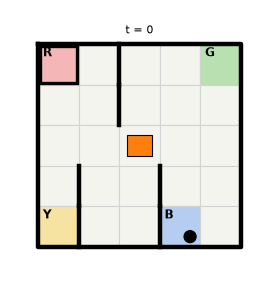

In [8]:
rng = np.random.default_rng(0)
state, info = env.reset(seed=1)
states, actions, total = [state], [], 0
while True:
    action = greedy_action(q_table, state, rng, info["action_mask"])
    state, reward, terminated, truncated, info = env.step(action)
    states.append(state)
    actions.append(action)
    total += reward
    if terminated or truncated:
        break
print("かかった回数:", len(actions), " 報酬の合計:", total)
print("選んだ行動:", ", ".join(ACTION_NAMES[a] for a in actions))

frames = []
for t, s in enumerate(states):
    label = f"t = {t}" + (f"  {ACTION_NAMES[actions[t - 1]]}" if t > 0 else "")
    fig, ax = plt.subplots(figsize=(3.4, 3.6), dpi=80)
    draw_taxi(ax, env, s, title=label)
    fig.canvas.draw()
    frames.append(np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy())
    plt.close(fig)
imageio.v3.imwrite(FIGURES / "ch05_walk.gif", frames + [frames[-1]] * 5, duration=500, loop=0)
print("GIF の枚数:", len(frames) + 5)
Image(filename=FIGURES / "ch05_walk.gif")

**期待する結果**（上の出力の読み方）: この回は 12 回の行動で客を送り届け、報酬の合計は 9 でした（移動と乗せる 11 回が各 -1、送り届けた 1 回が +20）。選んだ行動を見ると、東へ1マス、南へ2マス進んで乗り場 B で客を乗せ、北へ2マス、西へ3マス、北へ2マス進んで、乗り場 R で降ろしています。

GIF には、行動ごとの図 13 枚（t = 0〜12）に、最後の図を 5 枚足した 18 枚を書き込みます（送り届けた所で少し止めるため）。1 枚を 500 ミリ秒で表示します。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、4-3節の運転の GIF です。タクシーが乗り場 B で客を乗せて緑に変わり、真ん中の段を西へ回って、乗り場 R で客を降ろします。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、リポジトリを public にした後の 2026-10-10 に確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じ道のりのコマ送りの図を作ります。

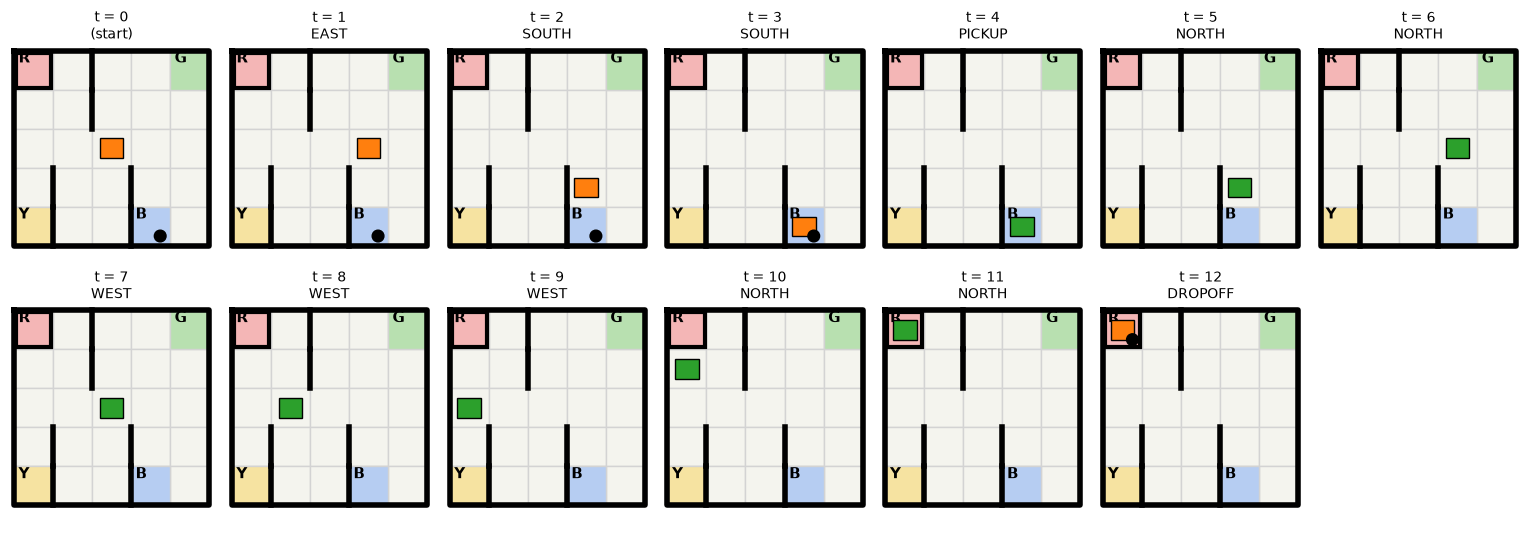

In [9]:
fig, axes = plt.subplots(2, (len(states) + 1) // 2, figsize=(2.2 * ((len(states) + 1) // 2), 5.6))
for ax in axes.flat:
    ax.axis("off")
for t, (ax, s) in enumerate(zip(axes.flat, states)):
    draw_taxi(ax, env, s, title=f"t = {t}" + (f"\n{ACTION_NAMES[actions[t - 1]]}" if t > 0 else "\n(start)"))
fig.tight_layout()
fig.savefig(FIGURES / "ch05_walk_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 4-3節の道のりの、すべての時点の図です。各図の上に、その時点までに選んだ行動を書いています。t = 4 の `PICKUP` でタクシーが緑（客が乗っている）に変わり、t = 12 の `DROPOFF` で、行き先の R（太い枠）に客を降ろしています。B から R へは、下の2段の壁を避けて、いったん真ん中の段（上から3段目）まで上がってから西へ進んでいます。

### 4-4. 学習曲線を見る

学習中のエピソードごとの報酬の合計を直前 50 回の平均にした線（上）と、そのエピソードで使った ε（下）を描きます。

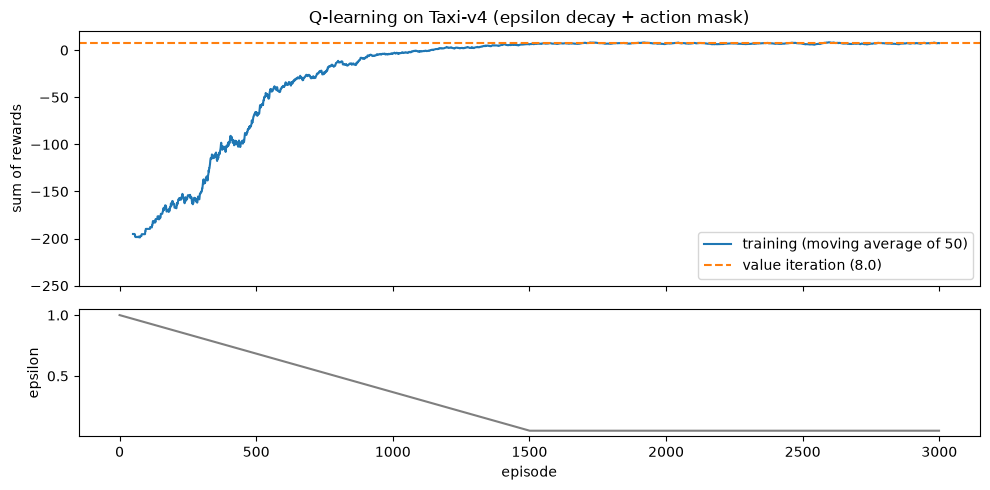

In [10]:
window = 50
moving = np.convolve(train_rewards, np.ones(window) / window, mode="valid")
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(np.arange(window - 1, len(train_rewards)), moving, color="tab:blue", label=f"training (moving average of {window})")
axes[0].axhline(vi_mean, color="tab:orange", linestyle="--", label=f"value iteration ({vi_mean:.1f})")
axes[0].set_ylabel("sum of rewards")
axes[0].set_ylim(-250, 20)
axes[0].set_title("Q-learning on Taxi-v4 (epsilon decay + action mask)")
axes[0].legend(loc="lower right")
axes[1].plot(epsilons, color="tab:gray")
axes[1].set_ylabel("epsilon")
axes[1].set_xlabel("episode")
fig.tight_layout()
fig.savefig(FIGURES / "ch05_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 上の青い線が、学習中の報酬の合計（直前 50 回の平均）、橙の破線が、4-2節で測った価値反復の方策の成績（8.0）です。下の灰色の線が、各エピソードで使った ε です。ε は 1.0 から一定の割合で下がり、1,500 回目で 0.05 になって、そのあとは変わりません。

青い線は、-200 に近い所から上がっていき、1,000 回あたりで 0 の少し下まで来ます。ε が 0.05 になる 1,500 回あたりから先は、橙の破線のすぐ下で、ほぼ横ばいです。

## 5. 読む(1)：Q 表

4節で学んだ Q 表の大きさと、3-2節の最初の状態の行を見ます。

In [11]:
print("Q 表の形:", q_table.shape)
print("一度も書き換えられなかった行（すべて 0 の行）の数:", int((q_table == 0).all(axis=1).sum()))
state, info = env.reset(seed=0)
print(f"状態 {state} の行:")
for a in range(6):
    allowed = "許される" if info["action_mask"][a] else "マスクで除外"
    print(f"  {ACTION_NAMES[a]:8s} {q_table[state, a]:7.2f}  （{allowed}）")

Q 表の形: (500, 6)
一度も書き換えられなかった行（すべて 0 の行）の数: 100
状態 314 の行:
  SOUTH      -7.83  （許される）
  NORTH      -1.30  （許される）
  EAST        0.00  （マスクで除外）
  WEST        0.00  （マスクで除外）
  PICKUP      0.00  （マスクで除外）
  DROPOFF     0.00  （マスクで除外）


**期待する結果**（上の出力の読み方）: Q 表は 500 行 × 6 列です。そのうち 100 行は、一度も書き換えられずに、すべて 0 のままでした。

3-2節の状態 314 の行では、許された `SOUTH`（-7.83）と `NORTH`（-1.30）だけが書き換えられていて、マスクで除外された4つの行動は 0.00 のままです。許された2つの中では `NORTH` が大きいので、学習後の方策は、この状態で北へ進みます。

Gymnasium 1.3.0 のソースの説明によると、500 個の状態のうち、客が行き先の乗り場にいる組み合わせ（25 × 4 = 100 個）は、エピソードの途中では現れません。一度も書き換えられなかった 100 行は、この数と合っています。

状態 314 の行では、マスクで除外された行動の 0.00 のほうが、許された行動の値（どちらもマイナス）より大きくなっています。Q 値が最大の行動を選ぶときに、マスクを使わずに行全体から選ぶと、許されていない行動を選んでしまいます。6-2節で見るように、サンプルでは、選ぶときも、目標を計算するときも、許された行動だけを見ています。

## 6. 読む(2)：Q学習のサンプル

4-1節のサンプルを読みます。Q 表を書き換える2行は、第3章の6-2節の Q学習と同じです。新しいのは、ε の決め方と、行動マスクの使い方です。

### 6-1. ε の減衰

```python
def epsilon_schedule(i, epsilon_start, epsilon_end, decay_episodes):
    if i >= decay_episodes:
        return epsilon_end
    return epsilon_start + (epsilon_end - epsilon_start) * i / decay_episodes
```

`i` 回目のエピソードで使う ε を返す関数です。最初（`i = 0`）は `epsilon_start`（1.0）で、`decay_episodes`（既定は学習の回数の半分）回目に `epsilon_end`（0.05）になるまで、一定の割合で減らします。そのあとは `epsilon_end` のままです。

ε が 1.0 のときは、すべての行動をでたらめに選びます（探索だけ）。Q 表がまだ何も知らない学習の始めは、いろいろな状態と行動を試すことを優先し、Q 表が育ってきたら、学んだ良い行動を選ぶこと（活用）を増やしていく、という考え方です。第3・4章では、ε を学習の間ずっと 0.1 にしていました。

### 6-2. 行動マスク

```python
mask = info["action_mask"] if use_mask else None
if rng.random() < epsilon:
    action = int(rng.choice(np.flatnonzero(mask))) if use_mask else int(rng.integers(env.action_space.n))
else:
    action = greedy_action(q_table, state, rng, mask)
```

`info["action_mask"]` は、3-3節で見た、6 つの行動のそれぞれが意味を持つか（1）、持たないか（0）の配列です。`np.flatnonzero(mask)` は、値が 1 の位置（許された行動の番号）を並べた配列なので、でたらめに選ぶときも、許された行動の中から選びます。Q 値が最大の行動を選ぶときも、`greedy_action` に `mask` を渡して、許された行動の中で最大のものを選びます。

```python
next_values = q_table[next_state][info["action_mask"] == 1] if use_mask else q_table[next_state]
target = reward if terminated else reward + gamma * next_values.max()
```

目標に使う「次の状態での最大の Q 値」も、次の状態で許された行動の中での最大にしています。マスクを使うと、許されない行動は選ばないので、その Q 値は書き換えられずに 0 のまま残ります。Taxi では、5節の状態 314 の行のように、許された行動の Q 値がどれもマイナスになることがあるので、0 のままの値を最大として拾ってしまわないように、ここでも許された行動だけを見ています。

マスクで除かれるのは、壁にぶつかる移動（その場から動かず、報酬は -1）と、見当違いの場所での乗せ降ろし（報酬は -10）です。どちらも、選んでも状態が変わらない行動です。

## 7. 比べる：工夫を外す

ε の減衰と行動マスクの効き目を確かめるため、次の4通りの設定で、同じ 3,000 回・同じ seed で学習させ、比べます。著者の環境では、このセル全体で 20 秒ほどかかりました。

| 設定 | ε | 行動マスク |
|---|---|---|
| A | 0.1 で一定（第3・4章と同じ） | 使わない |
| B | 1.0 → 0.05 に減らす | 使わない |
| C | 0.1 で一定 | 使う |
| D | 1.0 → 0.05 に減らす（4節と同じ） | 使う |

設定  最後の 100 回の平均  -10 の行動の回数   学習後の方策の平均  送り届けた割合


  A            2.9             5,691                6.56          99.3%


  B            6.0            32,682                0.97          96.6%


  C            5.7                 0                8.02         100.0%


  D            7.5                 0                8.02         100.0%


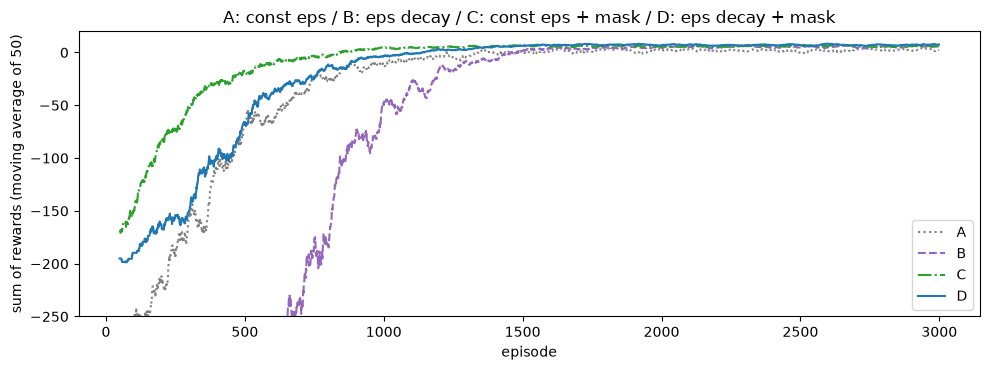

In [12]:
settings = {
    "A": dict(use_mask=False, epsilon_start=0.1, epsilon_end=0.1),
    "B": dict(use_mask=False),
    "C": dict(use_mask=True, epsilon_start=0.1, epsilon_end=0.1),
    "D": dict(use_mask=True),
}
curves = {}
print("設定  最後の 100 回の平均  -10 の行動の回数   学習後の方策の平均  送り届けた割合")
for name, kwargs in settings.items():
    q, rewards, illegal, _ = q_learning(env, episodes=3000, **kwargs)
    mean, delivered = evaluate(env, q, use_mask=kwargs["use_mask"])
    curves[name] = rewards
    print(f"  {name}   {rewards[-100:].mean():12.1f}   {illegal.sum():15,d}   {mean:17.2f}   {delivered:12.1%}")

fig, ax = plt.subplots(figsize=(10, 3.8))
styles = {"A": ("tab:gray", ":"), "B": ("tab:purple", "--"), "C": ("tab:green", "-."), "D": ("tab:blue", "-")}
for name, rewards in curves.items():
    moving = np.convolve(rewards, np.ones(window) / window, mode="valid")
    color, linestyle = styles[name]
    ax.plot(np.arange(window - 1, len(rewards)), moving, color=color, linestyle=linestyle, label=name)
ax.set_xlabel("episode")
ax.set_ylabel(f"sum of rewards (moving average of {window})")
ax.set_ylim(-250, 20)
ax.set_title("A: const eps / B: eps decay / C: const eps + mask / D: eps decay + mask")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "ch05_compare.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 表の4行が、4通りの設定の結果です。

- 行動マスクを使った C と D は、学習中に -10 の行動を一度も選ばず、学習後の方策は 8.02・100.0% です。マスクを使わない A と B は、学習後の方策が 6.56・99.3% と 0.97・96.6% で、送り届けられない回が残っています
- 学習中の最後の 100 回の平均は、ε を減らした B（6.0）が A（2.9）より、D（7.5）が C（5.7）より高くなっています
- -10 の行動の回数は、ε を減らした B が 32,682 回で、A（5,691 回）の 5 倍あまりです

図では、緑の一点鎖線の C が最も早く上がり、青の実線の D、灰色の点線の A が続きます。紫の破線の B は、650 回あたりまで縦軸の範囲（-250 まで）の下にあり、上がり始めるのが最も遅くなっています。1,500 回あたりから先は、4本とも 0 の近くに集まっています。

学習の始めの ε は、B・D が 1.0、A・C が 0.1 で、B・D は始めのうち、ほとんどの行動をでたらめに選びます。B はマスクを使わないので、でたらめに選んだ -10 の乗せ降ろしが、そのまま回数に表れています。学習の終わりの ε は、B・D が 0.05、A・C が 0.1 です。学習中の報酬には、でたらめに選んだ行動の分も含まれることを思い出してください（第3章の4-4節）。

この Taxi では、3,000 回の学習で見ると、学習後の方策の成績に大きく効いたのは行動マスクでした。著者が学習の seed を 0〜4 に変えて同じ4通りを測ったところ、マスクを使った C と D は、どの seed でも 8.02・100.0% でした。マスクを使わない A は 4.89〜7.01、B は 0.97〜6.64 で、B が A を下回ったのは 5 つの seed のうち 4 つでした。学習中の最後の 100 回の平均は、どの seed でも、ε を減らした B が A より、D が C より高くなりました（A が 1.7〜3.1、B が 4.5〜6.0、C が 5.7〜6.4、D が 6.8〜7.6）。この差には、学習の終わりの ε が 0.05 と、A・C の 0.1 の半分であることの分も含まれます。学習の回数を増やしたときの結果は、8-2節で見ます。

## 8. 遊んでみる

### 8-1. 雨の日の町

`is_rainy=True` を指定すると、雨で道が滑り、移動の行動を選んでも、思った向きへ進めるのは確率 0.8 で、残りは左右の向きへそれぞれ 0.1 の確率でずれます（乗せ降ろしはずれません）。4節と同じ設定で学ばせ、価値反復の方策と比べます。

In [13]:
rainy = gym.make("Taxi-v4", is_rainy=True)
rainy_q, rainy_rewards, _, _ = q_learning(rainy, episodes=3000)
mean, delivered = evaluate(rainy, rainy_q, use_mask=True)
vi_rainy_mean, vi_rainy_delivered = evaluate(rainy, value_iteration(rainy.unwrapped.P), use_mask=False)
print(f"学習後の方策（3,000 回）: 報酬の合計の平均 {mean:.2f}、客を送り届けた割合 {delivered:.1%}")
print(f"価値反復の方策:          報酬の合計の平均 {vi_rainy_mean:.2f}、客を送り届けた割合 {vi_rainy_delivered:.1%}")

学習後の方策（3,000 回）: 報酬の合計の平均 3.87、客を送り届けた割合 100.0%
価値反復の方策:          報酬の合計の平均 3.93、客を送り届けた割合 100.0%


**期待する結果**（上の出力の読み方）: 雨の日の町では、3,000 回学習した方策の報酬の合計の平均は 3.87、価値反復の方策は 3.93 で、どちらも 100.0% 客を送り届けています。晴れの日の町（4-2節の 8.022）より、どちらも低くなっています。

### 8-2. 学習の回数を増やす

7節の4通りを、学習の回数を 3,000 回から 5,000 回に増やして学ばせ直し、学習後の方策の成績だけを比べます。著者の環境では、このセル全体で 30 秒ほどかかりました。

In [14]:
for name, kwargs in settings.items():
    q, rewards, illegal, _ = q_learning(env, episodes=5000, **kwargs)
    mean, delivered = evaluate(env, q, use_mask=kwargs["use_mask"])
    print(f"{name}: 学習後の方策の報酬の合計の平均 {mean:.3f}、送り届けた割合 {delivered:.1%}、"
          f"学習中の最後の 100 回の平均 {rewards[-100:].mean():.1f}")

A: 学習後の方策の報酬の合計の平均 8.022、送り届けた割合 100.0%、学習中の最後の 100 回の平均 3.2


B: 学習後の方策の報酬の合計の平均 8.022、送り届けた割合 100.0%、学習中の最後の 100 回の平均 3.9


C: 学習後の方策の報酬の合計の平均 8.022、送り届けた割合 100.0%、学習中の最後の 100 回の平均 6.2


D: 学習後の方策の報酬の合計の平均 8.022、送り届けた割合 100.0%、学習中の最後の 100 回の平均 7.5


**期待する結果**（上の出力の読み方）: 5,000 回に増やすと、4通りすべてで、学習後の方策は 8.022・100.0% になりました。3,000 回では差があった A と B も、価値反復の方策と同じ成績に追いついています。学習中の最後の 100 回の平均は、A が 3.2、B が 3.9、C が 6.2、D が 7.5 で、ここには差が残っています。

**やってみよう**:

- 4-1節の `q_learning(env, episodes=3000)` の `seed` を変えたり（例: `q_learning(env, episodes=3000, seed=1)`）、エピソードの回数を減らしたりしてみてください。著者が seed を 0〜4 に変えて試したところ、3,000 回ではどれも 8.022・100.0% でした。2,000 回に減らすと、報酬の合計の平均は 1.46〜8.04、送り届けた割合は 96.8〜100.0% と、seed によって上下しました
- `q_learning` の `decay_episodes` を変えると、ε を 0.05 まで減らしきるまでの回数を変えられます（既定は学習の回数の半分）。学習曲線の形がどう変わるかを見てみましょう
- `gym.make("Taxi-v4", fickle_passenger=True)` にすると、客を乗せて最初に1マス動いたときに、客が確率 0.3 で行き先を変える、気まぐれな客になります（Gymnasium 1.3.0 のソースの説明による）。4節と同じ設定で学ばせて、成績を価値反復と比べてみてください

## 9. まとめ

この章では、状態が 500 個ある Taxi を、Q学習と、探索の2つの工夫で解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| 状態の番号・報酬・行動マスク・でたらめな運転の成績を見る | `decode()`、`info["action_mask"]` | 3節 |
| ε の減衰と行動マスクを使った Q学習で学ばせ、成績・運ぶ様子・学習曲線を見る | `q_learning()`、`evaluate()` | 4節 |
| 500 × 6 の Q 表を読む | `q_table` | 5節 |
| ε の減衰と行動マスクのコードを読む | `epsilon_schedule()`、`greedy_action()` | 6節 |
| 工夫を外した4通りを比べる | `use_mask`、`epsilon_start`・`epsilon_end` | 7節 |
| 雨の日の町、学習の回数を変えて試す | `is_rainy`、`episodes` | 8節 |

表が大きくなっても、Q学習の書き換えの2行は第3章と同じで、3,000 回の学習で、価値反復と同じ成績の方策にたどり着きました。行動マスクは、意味の無い行動（壁にぶつかる移動、見当違いの乗せ降ろし）を候補から外して、試す範囲を狭めます。7節の比べ方では、学習後の方策の成績に大きく効いたのは行動マスクでした（学習の seed を 0〜4 に変えても同じでした）。ε の減衰は、学習の始めに探索を、終わりに活用を多くする工夫で、学習中の終わりの報酬を上げました（学習の終わりの ε が小さい分も含みます）。ただし、マスクを使わない場合は、3,000 回の時点の学習後の方策の成績を、5 つの seed のうち 4 つで上げませんでした。seed 0 では、どの設定も、5,000 回学ばせると、価値反復と同じ成績になりました。

ここまでの第3〜5章の Q学習・SARSA は、1歩ごとに、次の状態の Q 値の見積もりを使って表を書き換える手法でした。第6章では、ブラックジャック（Blackjack）で、エピソードを最後まで終えてから、実際に得た報酬の合計で表を書き換えるモンテカルロ法を扱う予定です。

- 次に読むもの: 第6章 Blackjack（準備中）
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第6章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0 の動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。サンプルのコードは著者が書いたものです。

- T. G. Dietterich, "Hierarchical Reinforcement Learning with the MAXQ Value Function Decomposition", *Journal of Artificial Intelligence Research*, 13, 227–303, 2000（Taxi の問題の出どころ）
- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd edition, MIT Press, 2018（第2章 探索と活用、第6章 TD 学習〈Q学習〉）
- Farama Foundation, Gymnasium Documentation, Taxi: https://gymnasium.farama.org/environments/toy_text/taxi/
- Farama Foundation, Gymnasium 1.3.0 のソース `gymnasium/envs/toy_text/taxi.py`（状態の番号の決め方、報酬、行動マスク、雨の日の設定）: https://github.com/Farama-Foundation/Gymnasium/blob/v1.3.0/gymnasium/envs/toy_text/taxi.py

この章の図と GIF は、著者が matplotlib で描いたものです（Gymnasium の描画の絵は使っていません）。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。